## Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read in csv file 
df = pd.read_csv("../data/raw/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")

In [3]:
df.columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price'],
      dtype='str')

In [8]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,229851.000000,229851.000000,2.298510e+05
mean,96.717115,1996.512932,5.289914e+05
std,24.016049,14.341700,1.889871e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.890000e+05
50%,93.000000,1997.000000,5.000000e+05
75%,112.000000,2012.000000,6.350000e+05
max,366.700000,2022.000000,1.700000e+06


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 229851 entries, 0 to 229850
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                229851 non-null  str    
 1   town                 229851 non-null  str    
 2   flat_type            229851 non-null  str    
 3   block                229851 non-null  str    
 4   street_name          229851 non-null  str    
 5   storey_range         229851 non-null  str    
 6   floor_area_sqm       229851 non-null  float64
 7   flat_model           229851 non-null  str    
 8   lease_commence_date  229851 non-null  int64  
 9   remaining_lease      229851 non-null  str    
 10  resale_price         229851 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 19.3 MB


In [10]:
# list out all the data types of the columns
df.dtypes

month                      str
town                       str
flat_type                  str
block                      str
street_name                str
storey_range               str
floor_area_sqm         float64
flat_model                 str
lease_commence_date      int64
remaining_lease            str
resale_price           float64
dtype: object

In [11]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [12]:
# get distinct values of month
df['month'].sort_values().unique()

<StringArray>
['2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07',
 '2017-08', '2017-09', '2017-10',
 ...
 '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01',
 '2026-02', '2026-03', '2026-04']
Length: 112, dtype: str

#### Function to get specific year records for plots + Generate Distribution Plots

In [13]:
def get_specific_year_records(df: pd.DataFrame, year_str: str):
    """
    Filter the DataFrame to include only records where the 'month' column starts with the specified year string.
    The resulting DataFrame is sorted by the 'month' column.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing a 'month' column with year-month strings.
    year_str (str): The year string to filter the 'month' column by (e.g., '2020').

    Returns:
    pd.DataFrame: A filtered and sorted DataFrame containing only records from the specified year.
    """
    filtered_df = df[df["month"].str.startswith(year_str)].sort_values("month")
    return filtered_df

In [ ]:
def generate_plots(df: pd.DataFrame, x_axis: str, y_axis: str ="", plot_type: str = "bar", order: str = None, get_legend: bool = False, col_name: str = None, cat_col_variable: str = "flat_model"):
    """
    Generate a visualization plot based on the specified type from a pandas DataFrame.

    This function supports 'bar', 'line', 'count', 'box', and 'cat' (faceted) plots 
    using Seaborn, with a fallback to Matplotlib histograms for unsupported types. 
    It automatically inverts the y-axis for bar plots to display categories 
    from top to bottom.

    Parameters
    ----------
    df : pd.DataFrame
        The input pandas DataFrame containing the data to be plotted.
    x_axis : str
        The name of the column to be used for the x-axis (or single axis for count/hist).
    y_axis : str, optional
        The name of the column to be used for the y-axis. 
        - Required for 'bar', 'line', 'box', and 'cat' plots.
        - Used as the grouping variable (hue) for 'count' plots if `get_legend` is True.
        Default is an empty string.
    plot_type : str, optional
        The type of plot to generate. Supported values are:
        - "bar": Creates a horizontal bar plot (y-axis inverted). Uses `col_name` as hue if provided.
        - "line": Creates a line plot.
        - "count": Creates a categorical count plot.
        - "box": Creates a box plot.
        - "cat": Creates a faceted bar plot using `cat_col_variable` for column splitting.
                  Automatically sets titles and labels.
        - Other: Falls back to a Matplotlib histogram for continuous x-axis data.
        Default is "bar".
    order : list or None, optional
        A list of category values to define the order of the x-axis categories. 
        This is primarily used for 'count' plots. 
        If None, Seaborn will use the default sorting order (usually alphabetical or by appearance).
        Default is None.
    get_legend : bool, optional
        If True and `plot_type` is "count", the plot will use `y_axis` as the `hue` 
        to generate a legend instead of using the `order` parameter. 
        If False (default), the `order` parameter is applied to the x-axis.
        Default is False.
    col_name : str, optional
        The name of the column to use as the `hue` (grouping variable) for 'bar' plots.
        If None, no grouping is applied to the bar plot.
        For 'cat' plots, this string is used as the placeholder in the subplot title 
        (e.g., "{col_name}" becomes the value of the splitting column).
        Default is None.
    cat_col_variable : str, optional
        The name of the column to use for splitting the 'cat' plot into facets (columns).
        Only used when `plot_type` == "cat".
        Default is "flat_model".
    """
    if plot_type == "bar":
        sns.barplot(
            data=df,
            x=x_axis,
            y=y_axis,
            errorbar=None,
            color="coral",
            hue=col_name
        )
    
    elif plot_type == "line":
        sns.lineplot(
            data=df,
            x=x_axis,
            y=y_axis,
            errorbar=None
        )

    elif plot_type == "count":
        if get_legend:
            sns.countplot(data=df, x=x_axis, hue=y_axis)
        else:
            sns.countplot(data=df, x=x_axis, order=order)

    elif plot_type == "box":
        sns.boxplot(
            data=df,
            x=x_axis,
            y=y_axis
        )

    elif plot_type == "cat":
        sns.catplot(
            data=df,
            x=x_axis,
            y=y_axis,
            col=cat_col_variable,
            kind="bar",
            col_wrap=3,
            height=4,
            sharex=False
        ).set_titles("{col_name}") \
        .set_axis_labels(x_axis, f"Count of {x_axis}") \
        .set_xticklabels(rotation=45)
        plt.tight_layout()
        
    else: 
        plt.hist(df[x_axis])

In [ ]:
def generate_plot_labels(col: str, x_axis: str, y_axis: str = "Resale Price", legend: bool = False, legend_title: str = ""):
    """
    Configure and display plot labels, titles, and layout settings.

    This function sets the x-axis and y-axis labels, constructs a title based on 
    the provided column and y-axis labels, rotates x-axis tick labels for readability, 
    adjusts the layout to prevent clipping, and finally displays the plot. 
    It optionally adds a legend if requested.

    Parameters
    ----------
    col : str
        The label to include in the plot title. This typically represents a 
        specific category (e.g., a neighborhood, a year, or a group name).
        The title will be formatted as: "{y_axis} for {col}".
    x_axis : str
        The label for the x-axis.
    y_axis : str, optional
        The label for the y-axis.
        Default is "Resale Price".
    legend : bool, optional
        If True, adds a legend to the plot with the specified title.
        If False, no legend is added.
        Default is False.
    legend_title : str, optional
        The title for the legend. Used only if `legend=True`.
        Default is an empty string.
    """

    if legend:
        plt.legend(
            title=legend_title,
            bbox_to_anchor=(1.05, 1),
            loc="upper left"
        )

    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.title(f"{y_axis} for {col}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Get Distributions of Columns

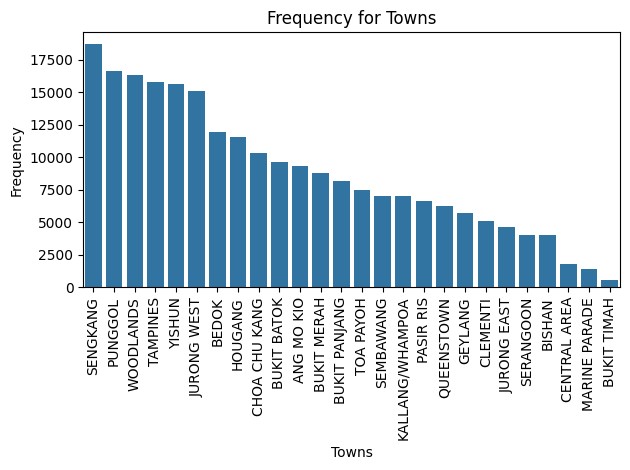

In [61]:
# get the counts of residents according to town
order = df["town"].value_counts().index
generate_plots(df=df, x_axis="town", plot_type= "count", order=order)
generate_plot_labels("Towns", x_axis="Towns", y_axis="Frequency")

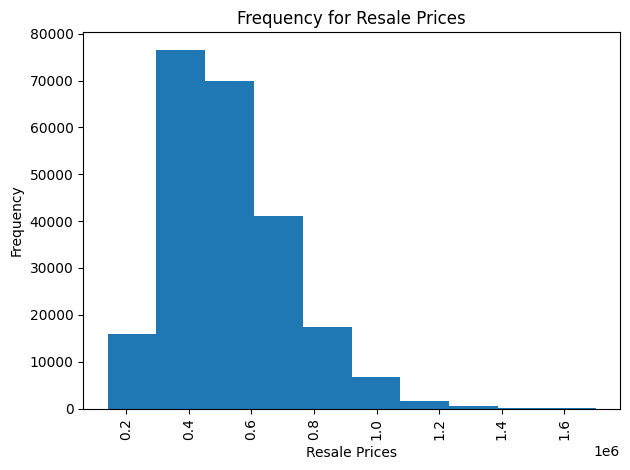

In [ ]:
# Get the distribution of the numeric variable
generate_plots(df=df, x_axis="resale_price", plot_type= "hist")
generate_plot_labels("Resale Prices", x_axis="Resale Prices", y_axis="Frequency")

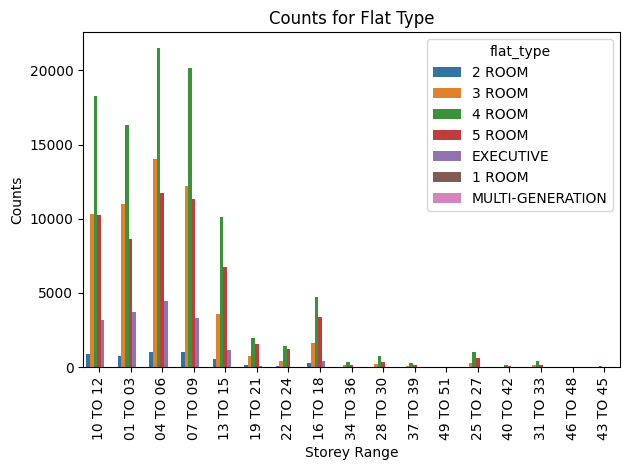

In [ ]:
# number of storeys according to flat type (no. of rooms)
generate_plots(df=df, x_axis="storey_range", y_axis="flat_type", plot_type="count", get_legend=True)
generate_plot_labels("Flat Type", x_axis="Storey Range", y_axis="Counts")

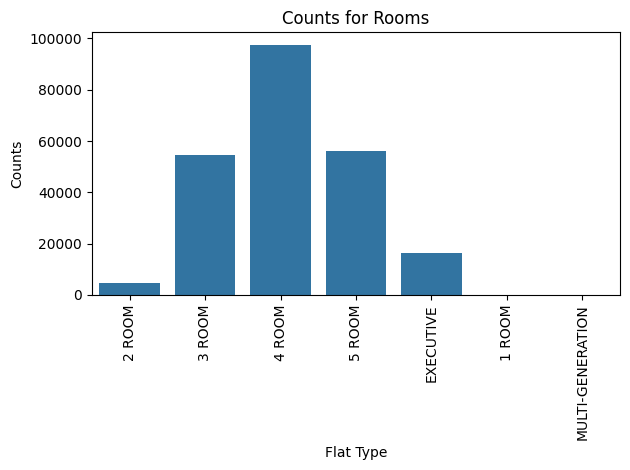

In [ ]:
# counts of the number of rooms
generate_plots(df=df, x_axis="flat_type", plot_type="count")
generate_plot_labels("Rooms", x_axis="Flat Type", y_axis="Counts")

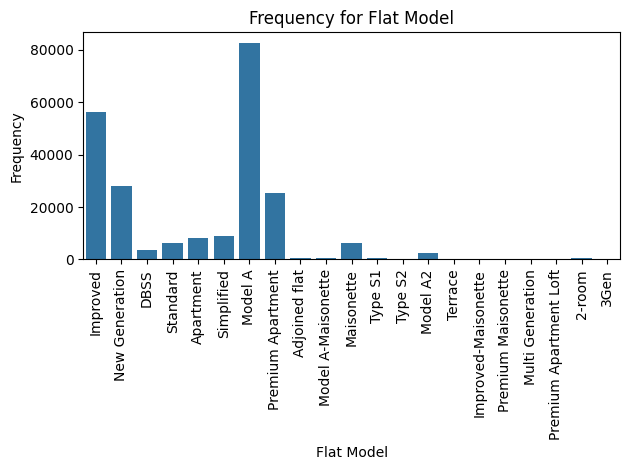

In [68]:
# counts of the housing types
generate_plots(df=df, x_axis="flat_model", plot_type="count")
generate_plot_labels("Flat Model", x_axis="Flat Model", y_axis="Frequency")

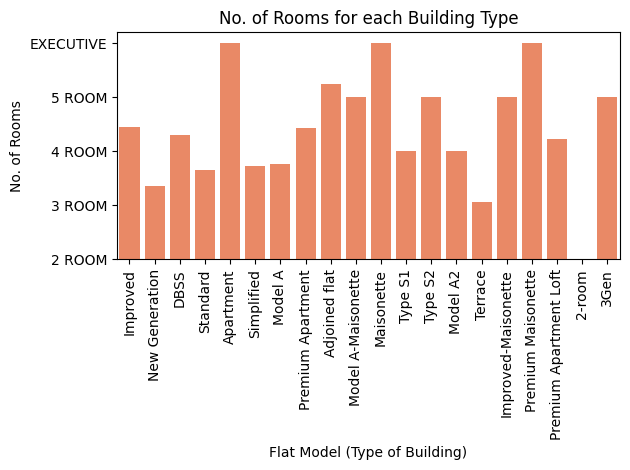

In [ ]:
# Top 5 most common number of room based on Flat Model (type of building)

top5_common_room_no = df["flat_type"].value_counts().nlargest(5).index
df_top5_flat_types = df[df["flat_type"].isin(top5_common_room_no)]
generate_plots(df=df_top5_flat_types, x_axis="flat_model", y_axis="flat_type")
generate_plot_labels("each Building Type", x_axis="Flat Model (Type of Building)", y_axis="No. of Rooms")

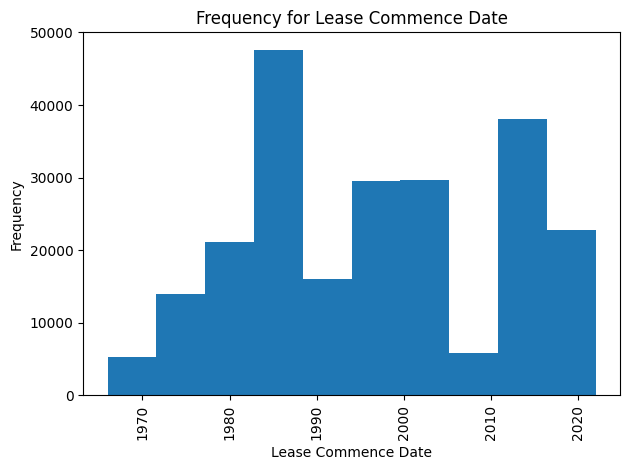

In [ ]:
# get the distribution of the lease start dates
generate_plots(df, x_axis="lease_commence_date", plot_type="hist")
generate_plot_labels("Lease Commence Date", x_axis="Lease Commence Date", y_axis="Frequency")

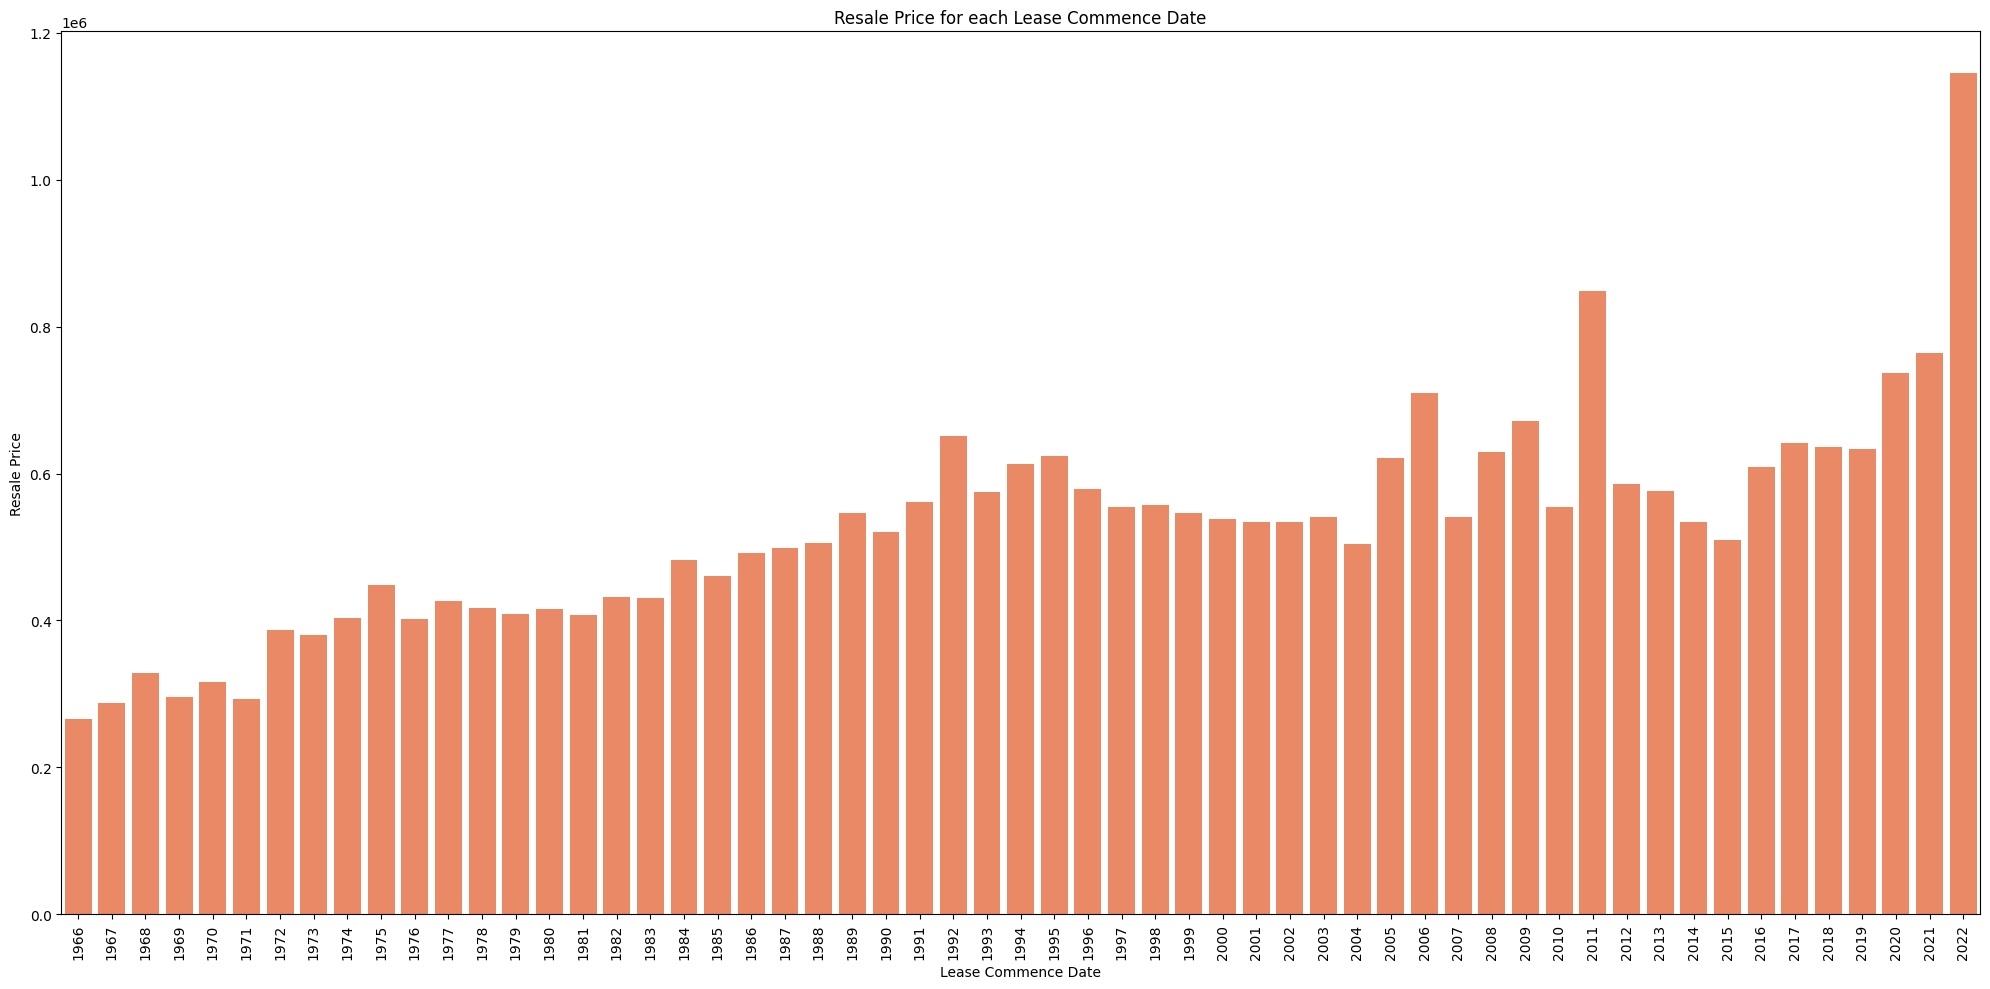

In [ ]:
# The resale price according to the Lease Commence Date
plt.figure(figsize=(20, 10))
generate_plots(df=df, x_axis="lease_commence_date", y_axis="resale_price")
generate_plot_labels("each Lease Commence Date", x_axis="Lease Commence Date")

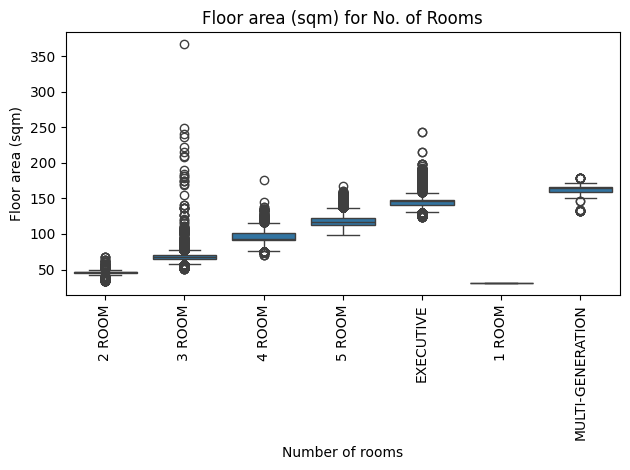

In [ ]:
# distribution of size based on the no. of rooms 
generate_plots(df=df, x_axis="flat_type", y_axis="floor_area_sqm", plot_type="box")
generate_plot_labels("No. of Rooms", x_axis="Number of rooms", y_axis="Floor area (sqm)")

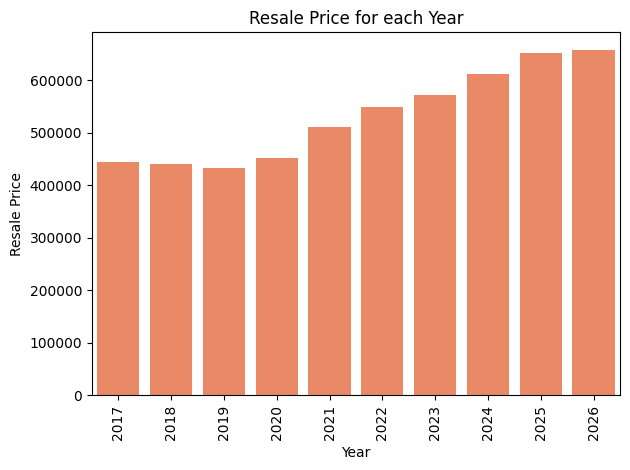

In [ ]:
# Plots of Resale prices by Year
years = df['month'].str.split('-').str[0]
generate_plots(df=df, x_axis=years, y_axis="resale_price")
generate_plot_labels("each Year", x_axis="Year")

C:\Users\Graw2x\AppData\Local\Temp\ipykernel_21428\2974949003.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.barplot(


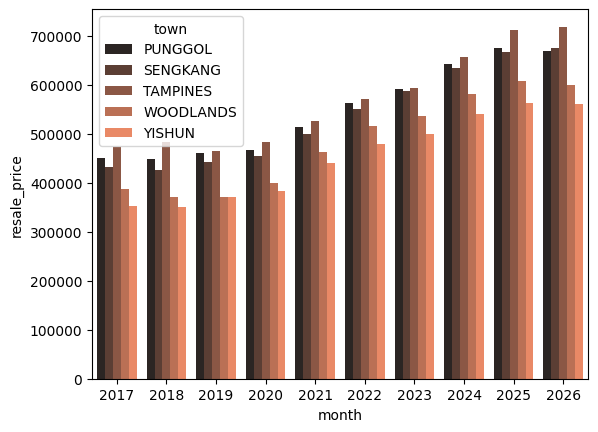

In [ ]:
# Top 5 towns where Residents Live (Resale prices according to year)

top5_town = df["town"].value_counts().nlargest(5).index
df_top5 = df[df["town"].isin(top5_town)] 
generate_plots(df=df_top5, x_axis=years, y_axis="resale_price", col_name="town")

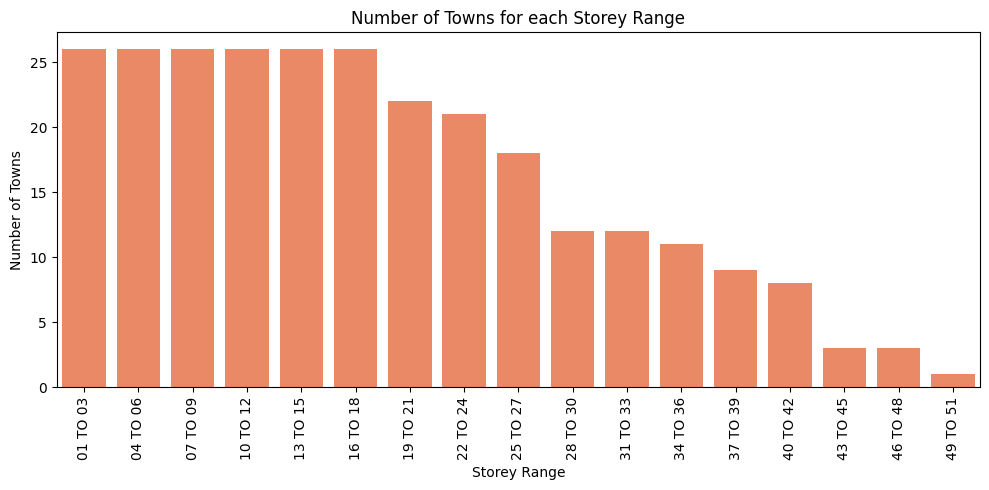

In [ ]:
# get the count of the no. of unique towns for each storey range
town_counts = (
    df.groupby("storey_range")["town"]
      .nunique()
      .reset_index(name="town_count")
)

plt.figure(figsize=(10, 5))
generate_plots(df=town_counts, x_axis="storey_range", y_axis="town_count")
generate_plot_labels("each Storey Range", x_axis="Storey Range", y_axis="Number of Towns")

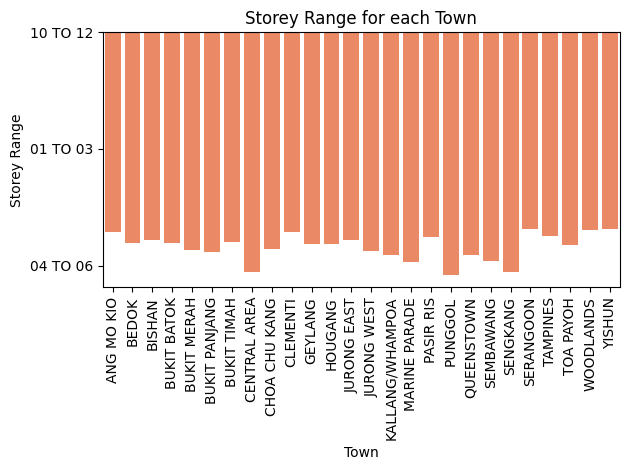

In [ ]:
# Get the top 5 storey range for each town

top5_storey_range = df["storey_range"].value_counts().nlargest(5).index
df_top5_storey_range = df[df["storey_range"].isin(top5_storey_range)]
generate_plots(df=df_top5_storey_range, x_axis="town", y_axis="storey_range")
generate_plot_labels("each Town", x_axis="Town", y_axis="Storey Range")

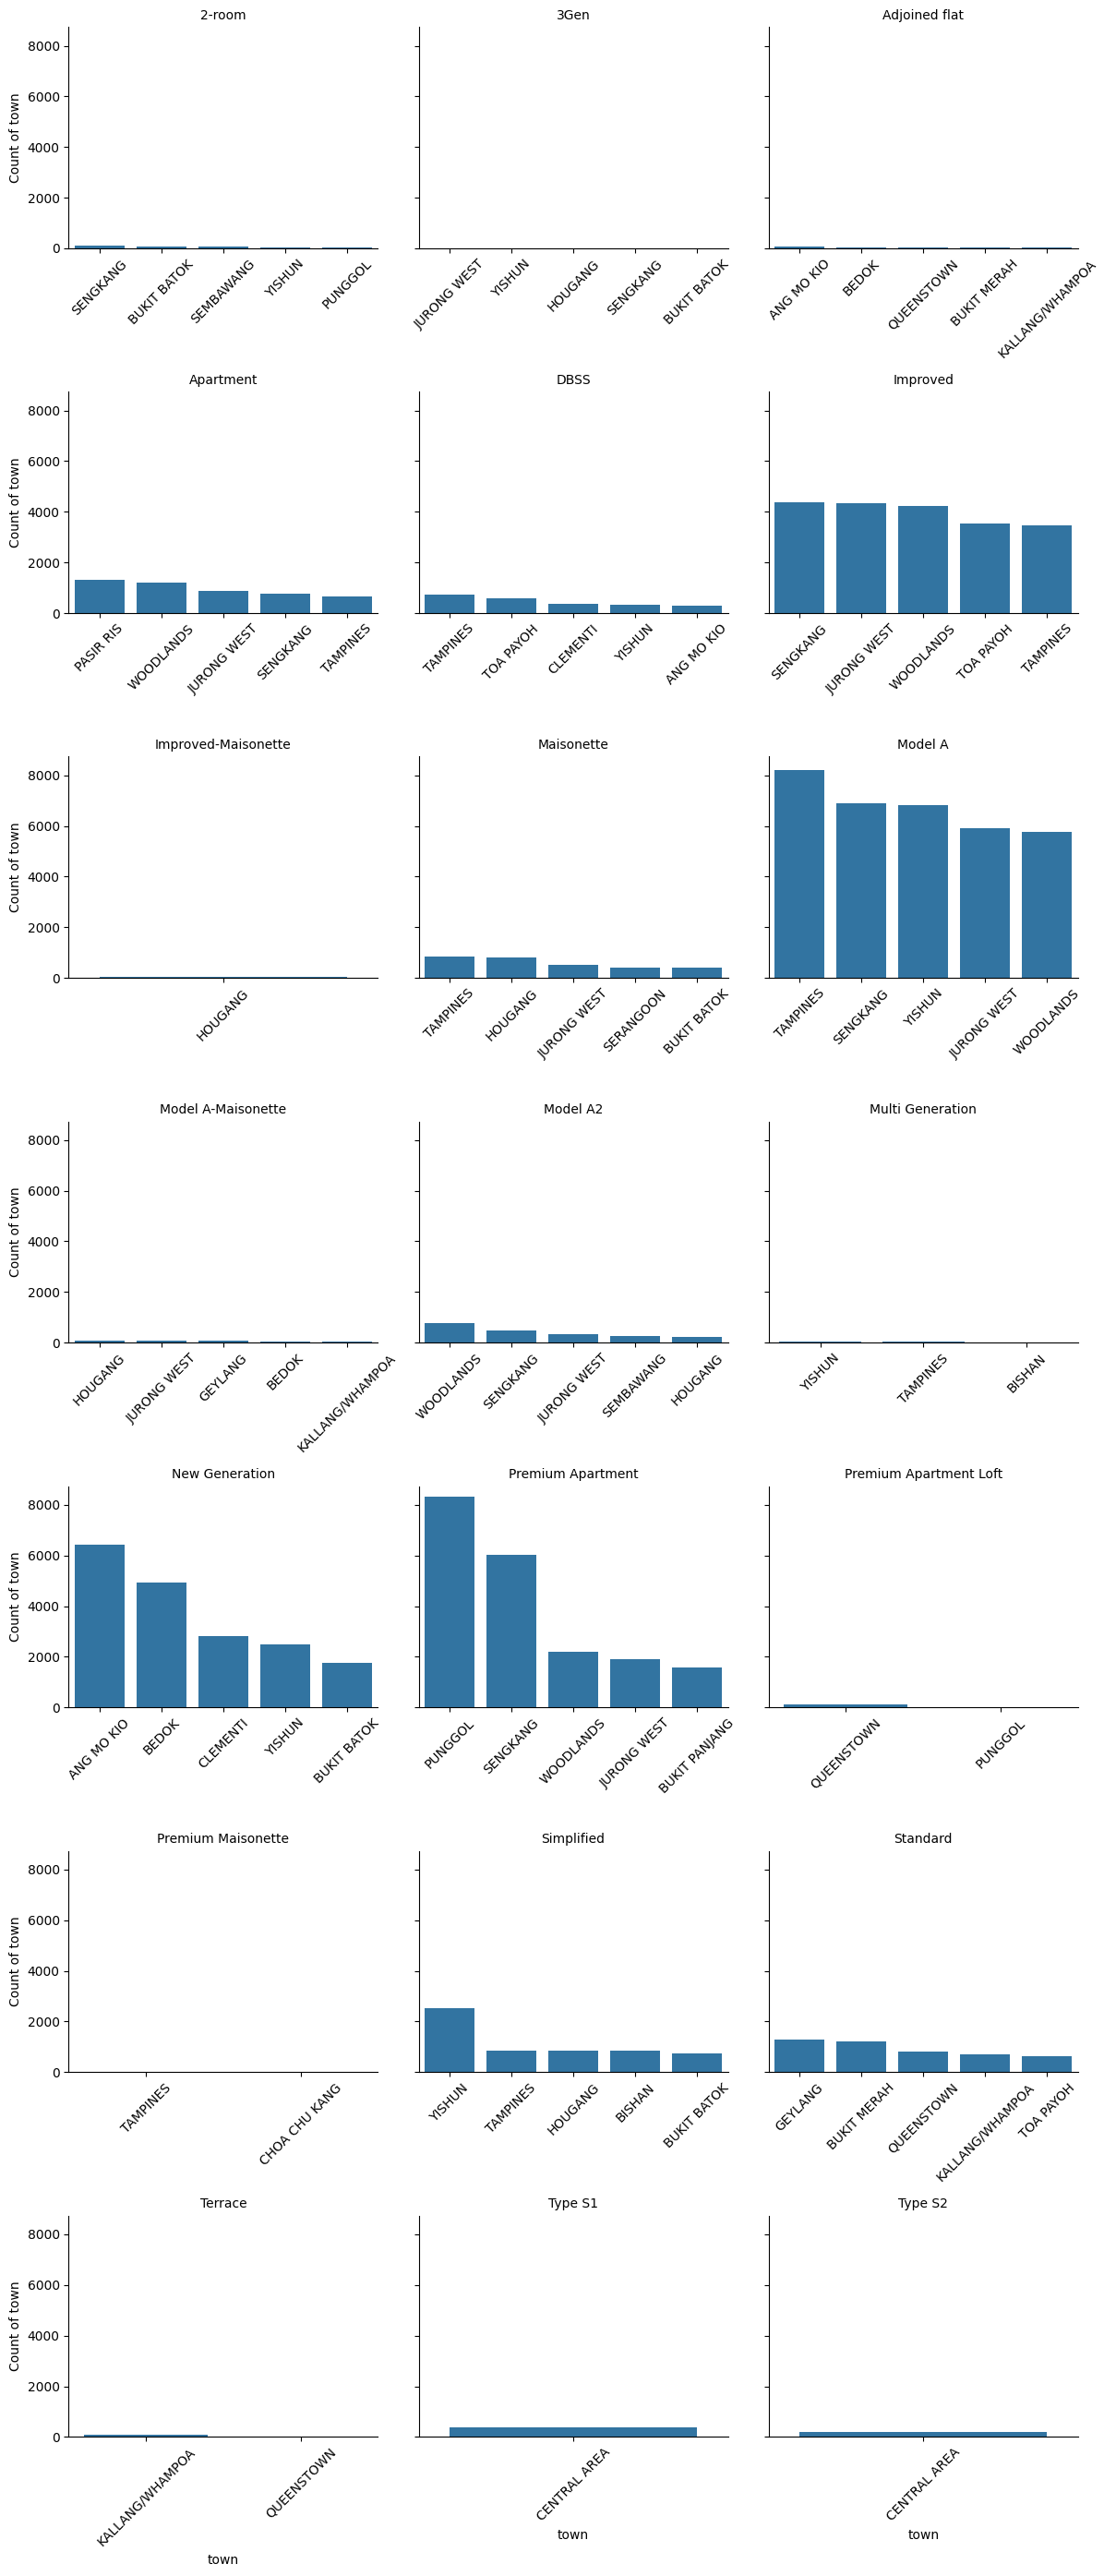

In [96]:
# top 5 towns of each flat model
top5_towns_per_model = (
    df.groupby(["flat_model", "town"])
      .size()
      .reset_index(name="count")
      .sort_values(["flat_model", "count"], ascending=[True, False])
      .groupby("flat_model")
      .head(5)
)
generate_plots(df=top5_towns_per_model, x_axis="town", y_axis="count", plot_type="cat")

In [29]:
# List of all the years under analysis
year_list = ['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']

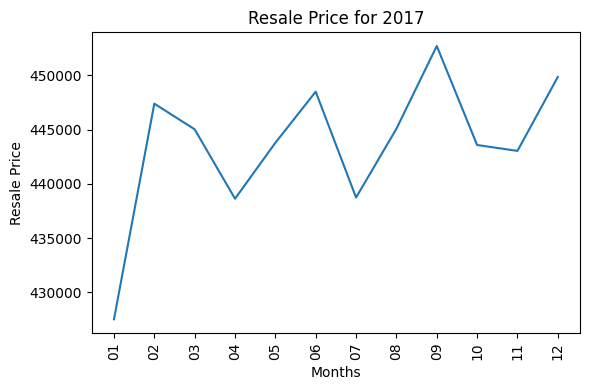

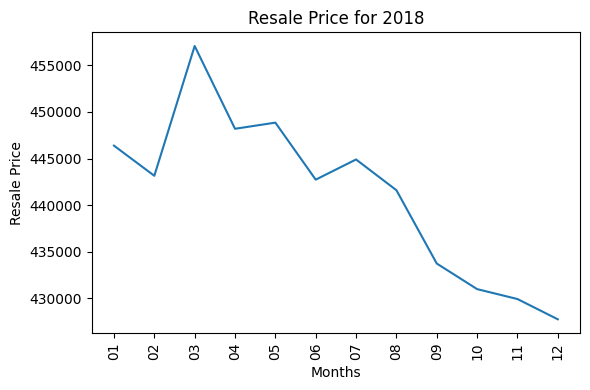

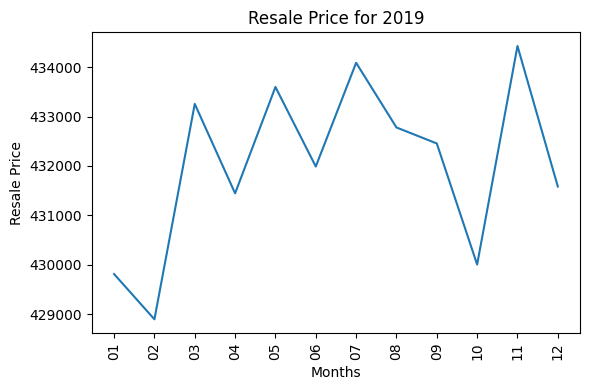

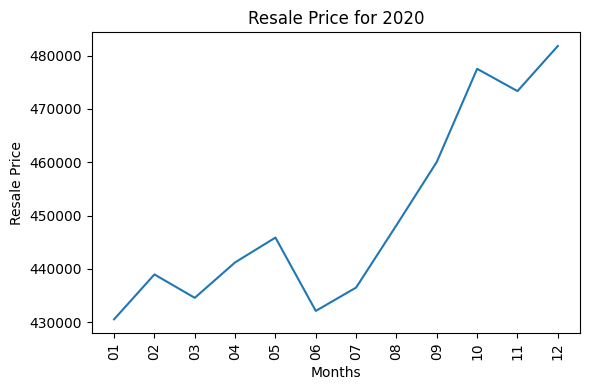

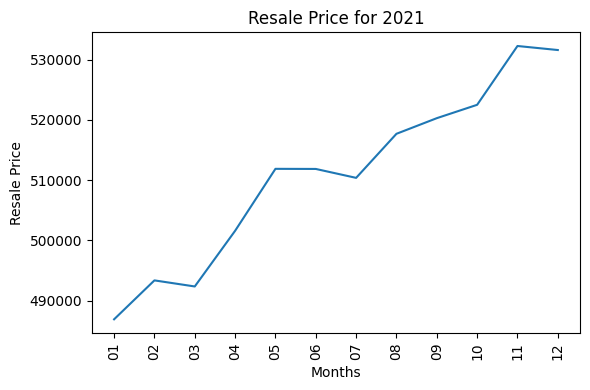

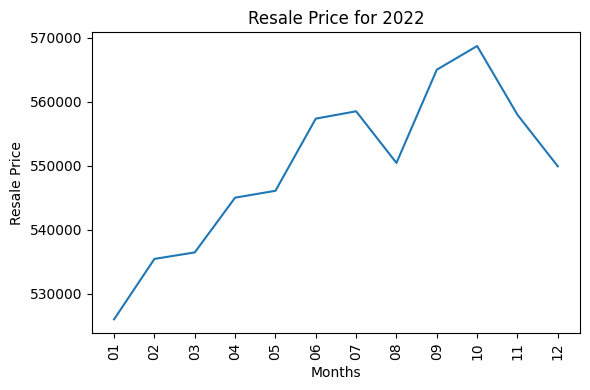

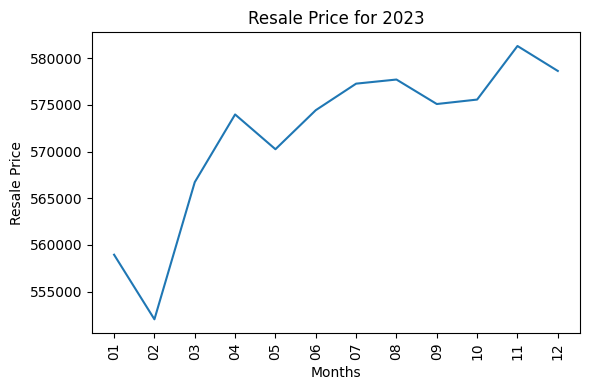

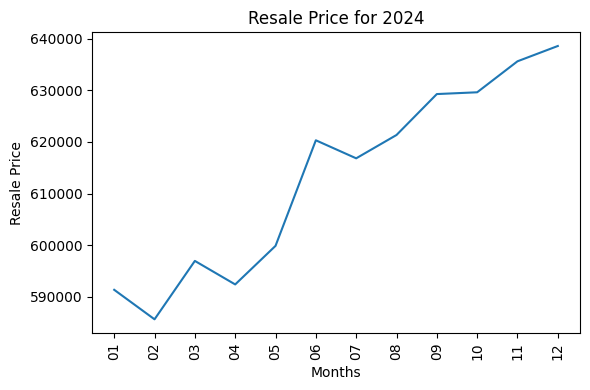

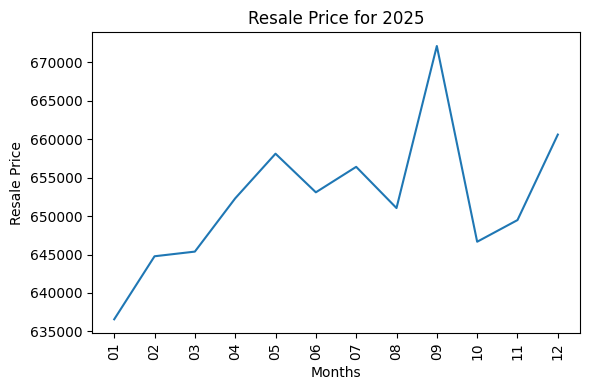

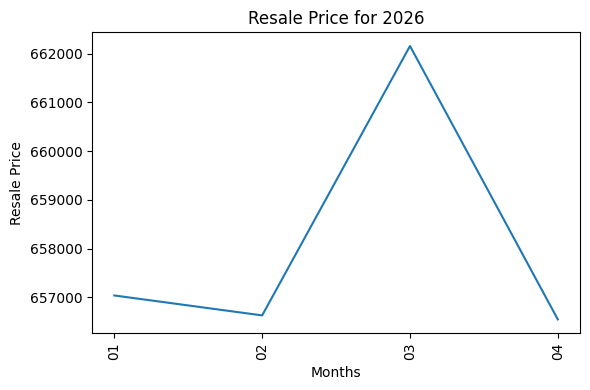

In [ ]:
# Plots of resale prices for each year and within the months of each year 
for i in year_list:
    df_by_year = get_specific_year_records(df=df, year_str=i)
    plt.figure(figsize=(6, 4))
    generate_plots(df=df_by_year, x_axis=df_by_year['month'].str.split('-').str[1], y_axis= "resale_price", plot_type="line")
    generate_plot_labels(col=i, x_axis="Months")

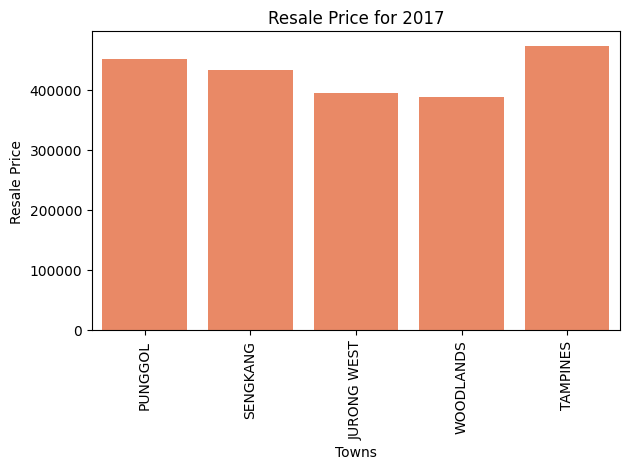

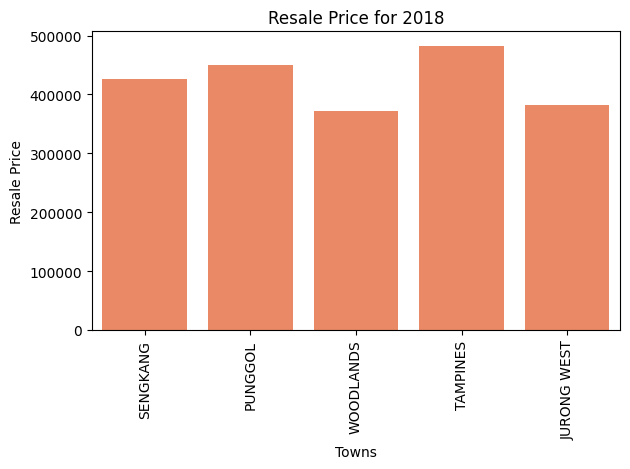

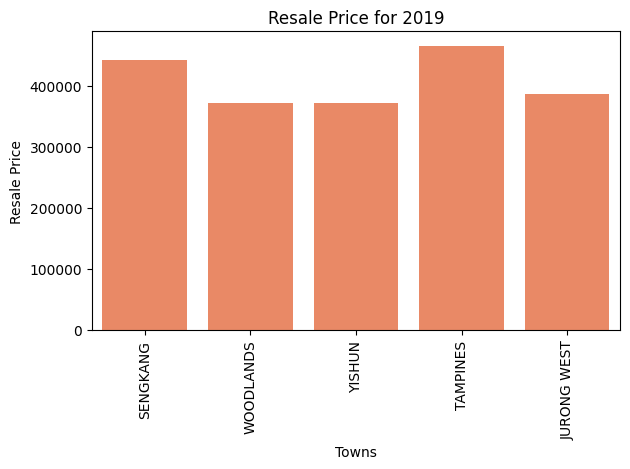

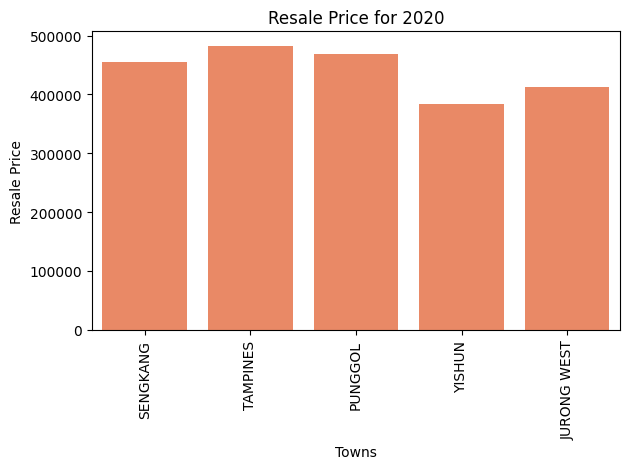

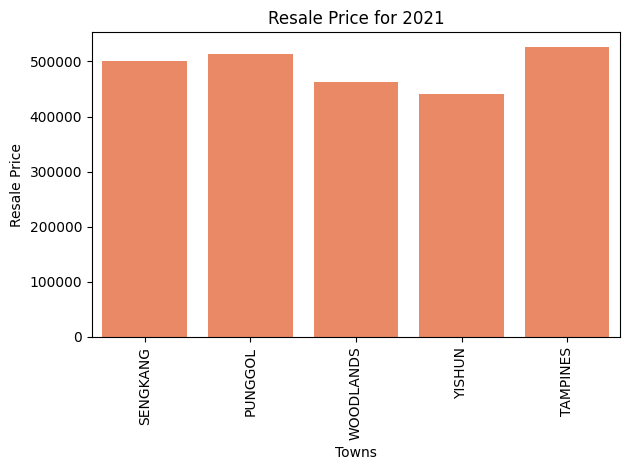

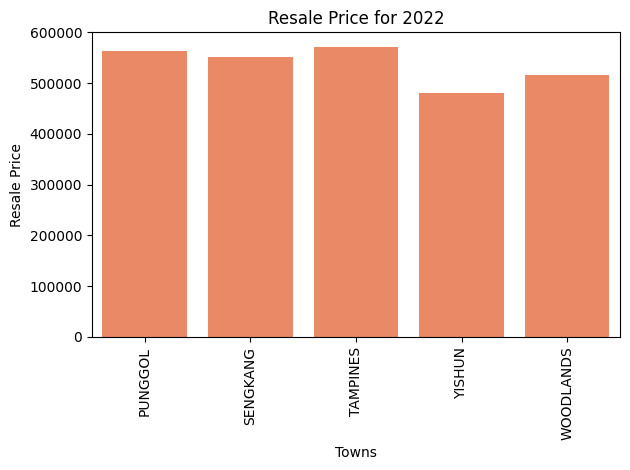

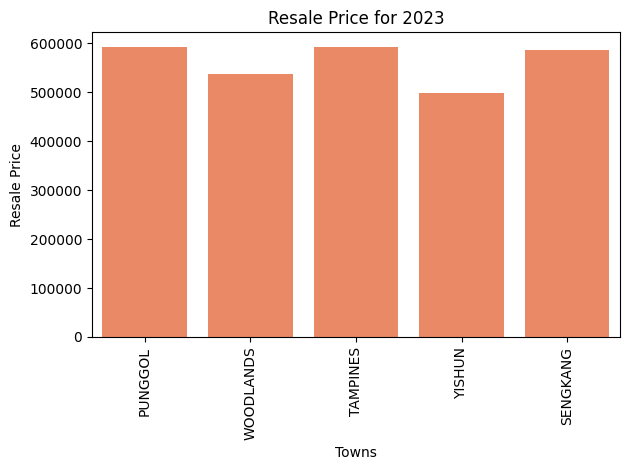

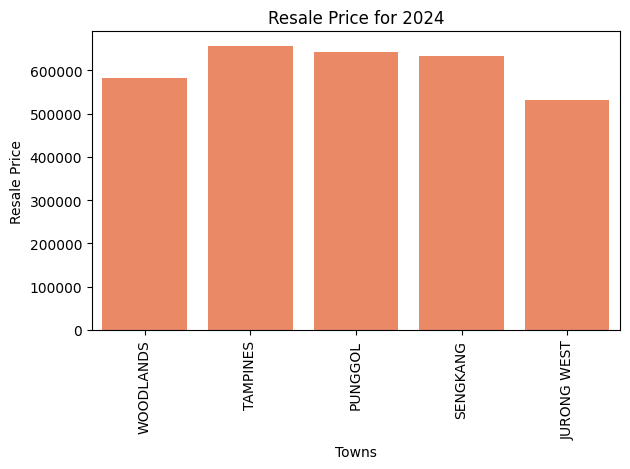

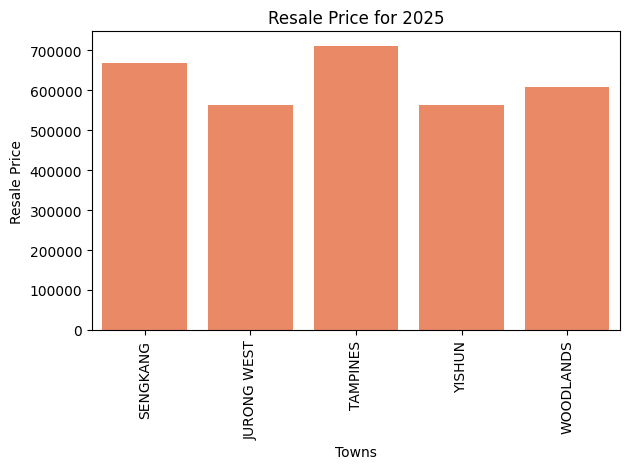

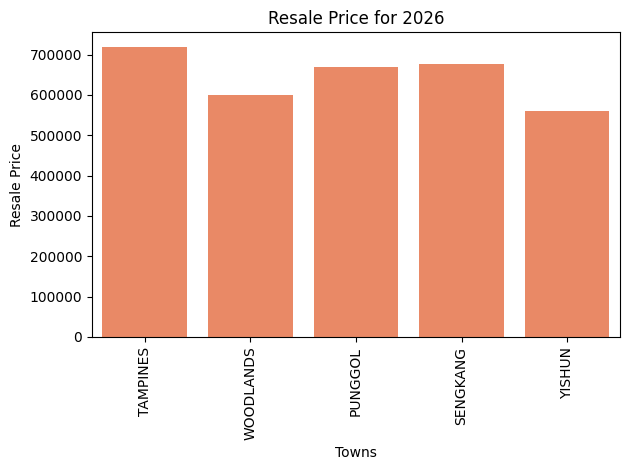

In [ ]:
# Plots of the top 5 towns with the highest resale price based on year
for i in year_list:
    df_by_year = get_specific_year_records(df=df, year_str=i)
    
    # Get top 5 towns for this year and filter the DataFrame
    top5_towns = df_by_year["town"].value_counts().nlargest(5).index
    df_top5 = df_by_year[df_by_year["town"].isin(top5_towns)]
    generate_plots(df=df_top5, x_axis="town", y_axis="resale_price")
    generate_plot_labels(col=i, x_axis="Towns")

C:\Users\Graw2x\AppData\Local\Temp\ipykernel_21428\2974949003.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.barplot(


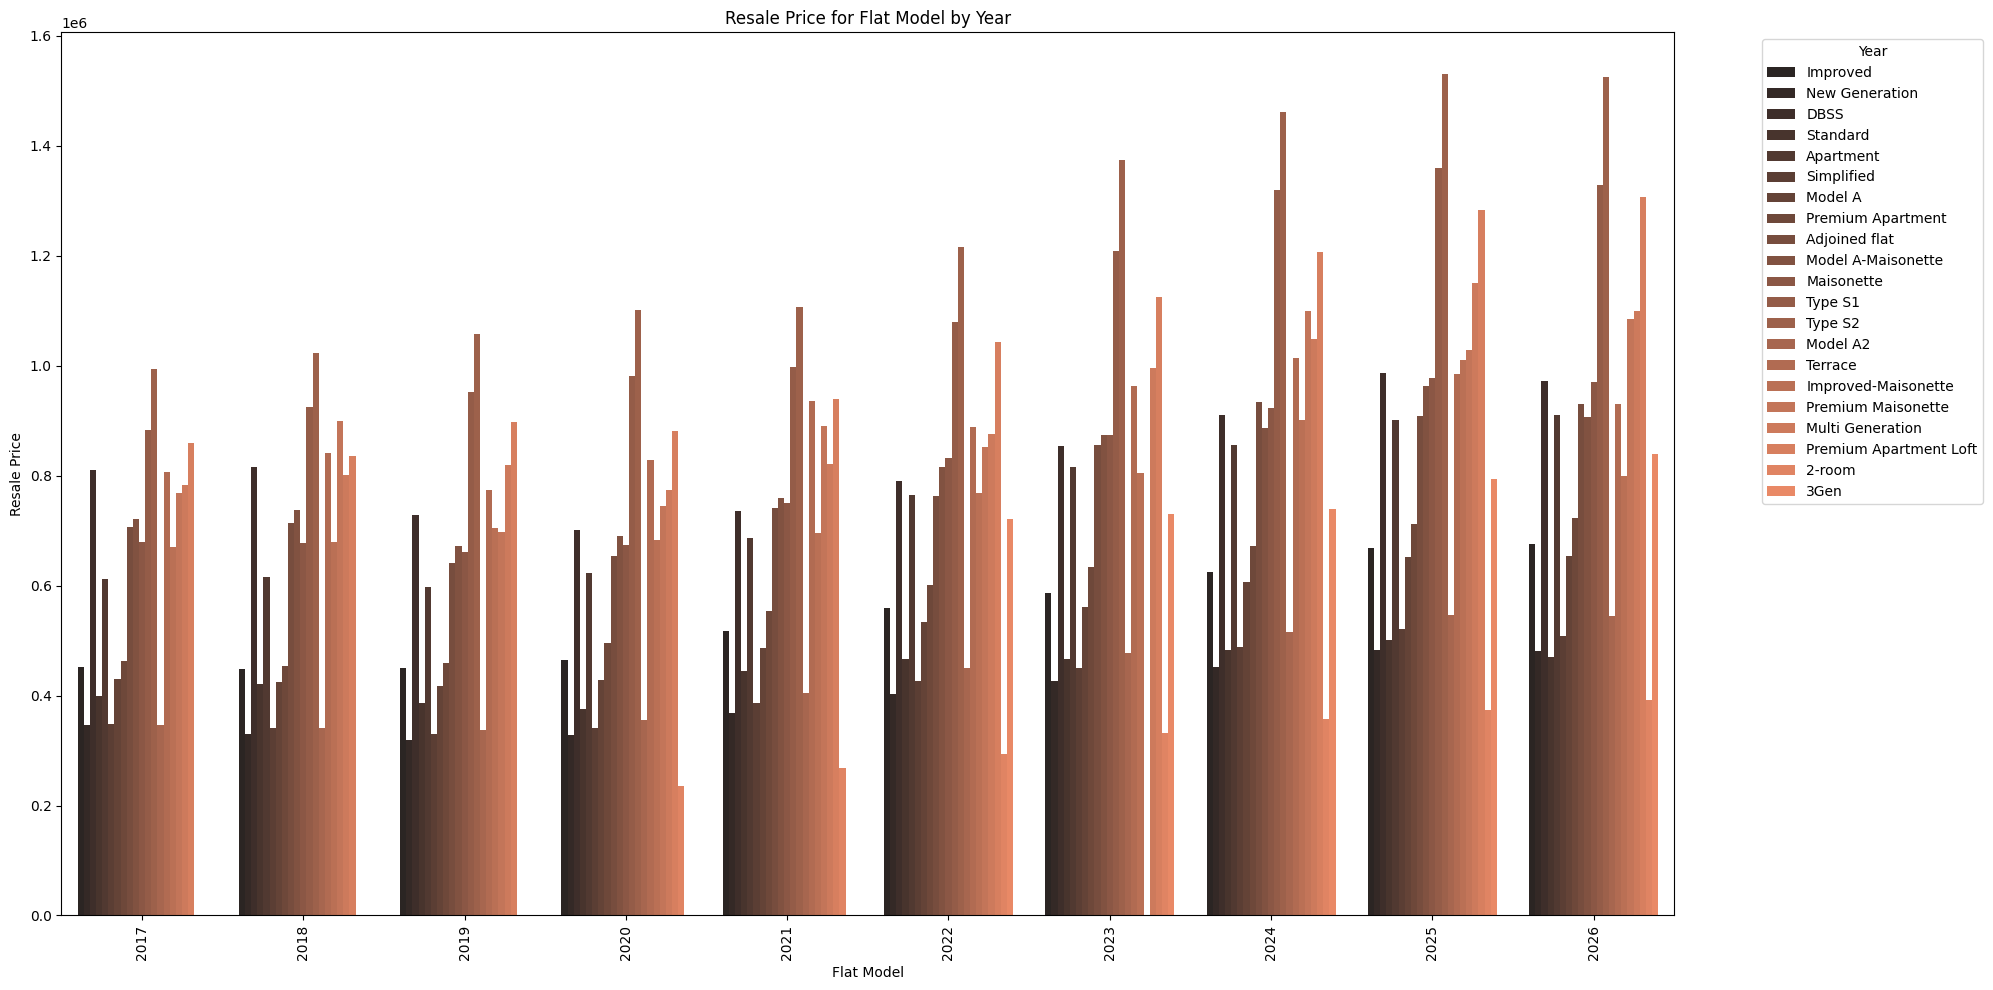

In [ ]:
# Resale prices of flat models according to year
plt.figure(figsize=(20, 10))
generate_plots(df=df, x_axis=years, y_axis="resale_price", col_name="flat_model")
generate_plot_labels(col='Flat Model by Year', x_axis="Flat Model", legend=True, legend_title="Year")

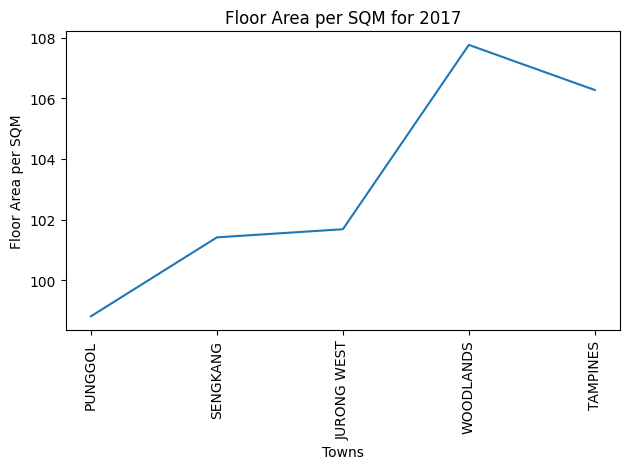

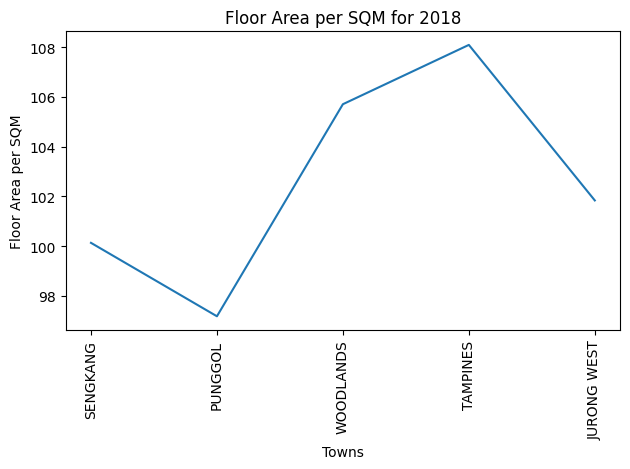

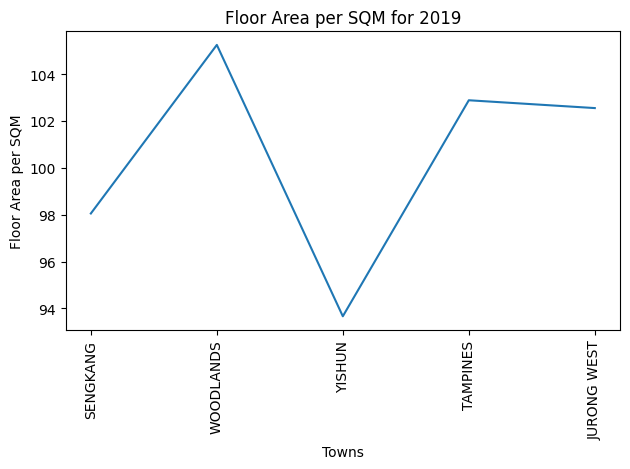

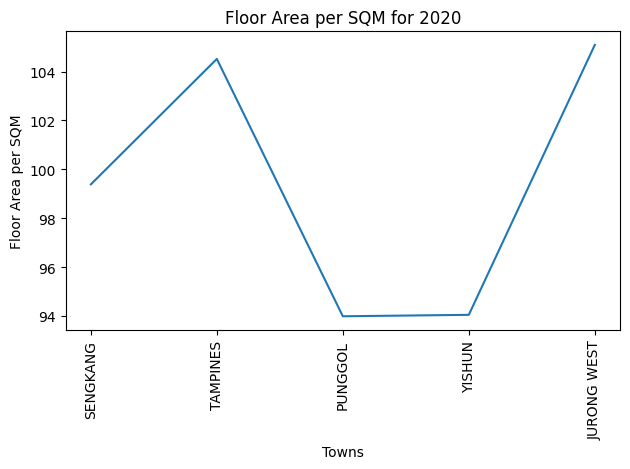

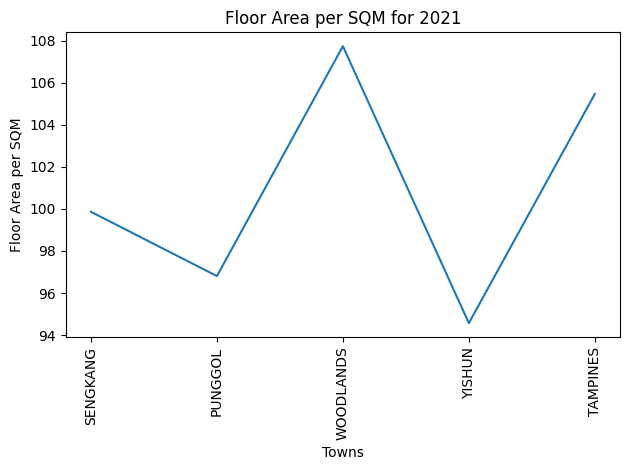

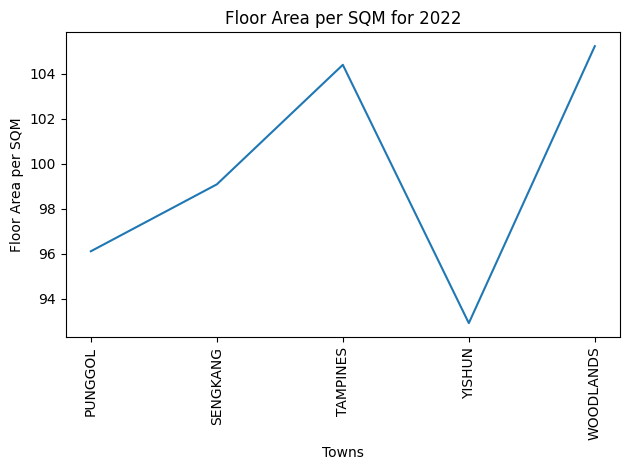

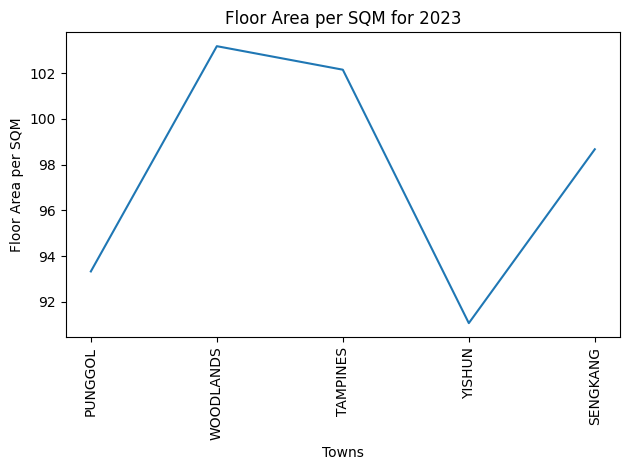

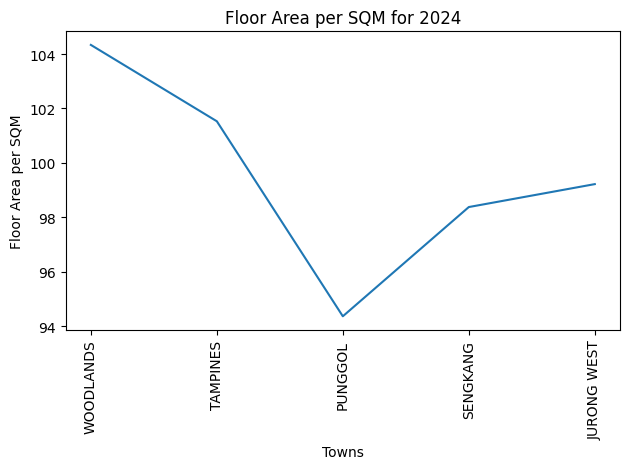

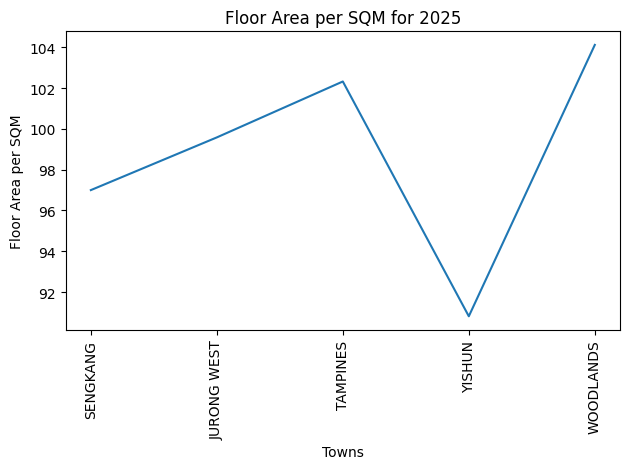

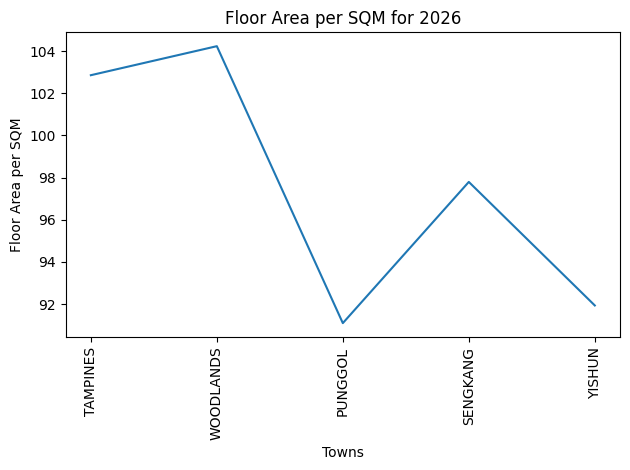

In [ ]:
# floor_area_sqm for the top 5 towns with the highest resale price 
# make a line chart for this since theres lots of numeric values

for i in year_list:
    df_by_year = get_specific_year_records(df=df, year_str=i)
    
    # Get top 5 towns for this year and filter the DataFrame
    top5_towns = df_by_year["town"].value_counts().nlargest(5).index
    df_top5 = df_by_year[df_by_year["town"].isin(top5_towns)]
    
    generate_plots(df=df_top5, x_axis="town", y_axis="floor_area_sqm", plot_type="line")
    generate_plot_labels(col=i, x_axis="Towns", y_axis="Floor Area per SQM")


In [33]:
# observe for any correlation between all numeric variables only
# dropping lease_commence_date as this is a year variable and not a valid numeric value
df.drop(columns=["lease_commence_date"]).corr(numeric_only=True)

,floor_area_sqm,resale_price
floor_area_sqm,1.000000,0.567971
resale_price,0.567971,1.000000
